In [6]:
import torch
from torchvision import datasets, transforms

In [18]:
data_dir1 = "/kaggle/input/leukemia-classification/C-NMC_Leukemia/training_data/fold_0"
data_dir2 = "/kaggle/input/leukemia-classification/C-NMC_Leukemia/training_data/fold_1"
data_dir3 = "/kaggle/input/leukemia-classification/C-NMC_Leukemia/training_data/fold_2"

In [19]:
dataset1 = datasets.ImageFolder(data_dir1)
dataset2 = datasets.ImageFolder(data_dir2)
dataset3 = datasets.ImageFolder(data_dir3)

In [41]:
datasets_all = torch.utils.data.ConcatDataset([dataset1, dataset2, dataset3])
data_train, data_test = torch.utils.data.random_split(datasets_all, [0.8, 0.2])

img, label = data_train[2000]

In [43]:
train_transform = transforms.Compose(
    [transforms.Resize([224, 224]),
     transforms.CenterCrop(180),
     transforms.RandomRotation(180),
     transforms.ToTensor()
    ] 
)

test_transform = transforms.Compose(
    [transforms.Resize([224, 224]),
     transforms.CenterCrop(180),
     transforms.ToTensor()
    ] 
)

In [44]:
transformed_img = train_transform(img)
print(transformed_img.shape)

torch.Size([3, 180, 180])


In [51]:
from torch.utils.data import Dataset, DataLoader

class TransformDataset(Dataset):
    def __init__(self, dataset, transformer):
        self.dataset = dataset
        self.transformer = transformer

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        img, label = self.dataset[idx]

        img_new = self.transformer(img)

        return img_new, label

In [54]:
train_data = TransformDataset(data_train, train_transform)

In [49]:
test_data = TransformDataset(data_test, test_transform)

2132

In [58]:
train_loader = DataLoader(train_data, batch_size=256)
test_loader = DataLoader(test_data, batch_size=256)

In [59]:
for img, idx in test_loader:
    print(img.shape)
    print(idx.shape)

torch.Size([256, 3, 180, 180])
torch.Size([256])
torch.Size([256, 3, 180, 180])
torch.Size([256])
torch.Size([256, 3, 180, 180])
torch.Size([256])
torch.Size([256, 3, 180, 180])
torch.Size([256])
torch.Size([256, 3, 180, 180])
torch.Size([256])
torch.Size([256, 3, 180, 180])
torch.Size([256])
torch.Size([256, 3, 180, 180])
torch.Size([256])
torch.Size([256, 3, 180, 180])
torch.Size([256])
torch.Size([84, 3, 180, 180])
torch.Size([84])


(180, 180, 3)


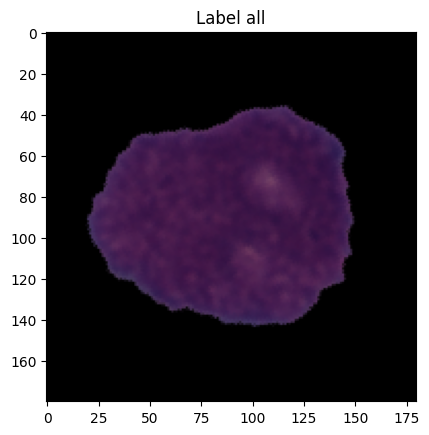

(180, 180, 3)


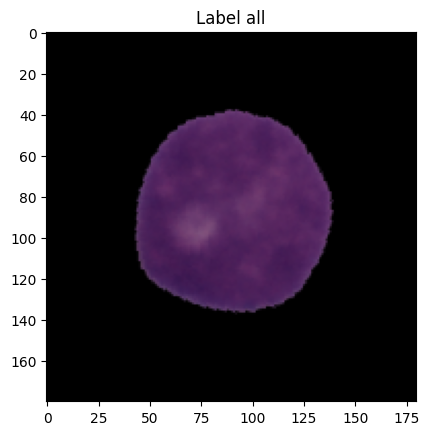

(180, 180, 3)


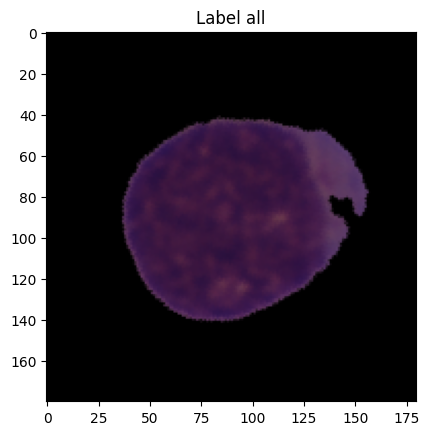

In [61]:
import matplotlib.pyplot as plt

for i in range(3):  # Show 3 images

    # Get the image data (tensor) and convert it back to a NumPy array for manipulation
    img, y = train_data[i]
    img = img.numpy()
    
    # Convert the color channels from (channels, height, width) to (height, width, channels) for pyplot
    img = img.transpose((1, 2, 0))
    print(img.shape)
    
    # Get the label name from the dataset class labels
    label = dataset.classes[y]

    # Plot the image with a title (including label name)
    plt.imshow(img)
    plt.title(f"Label {label}")
    plt.show()

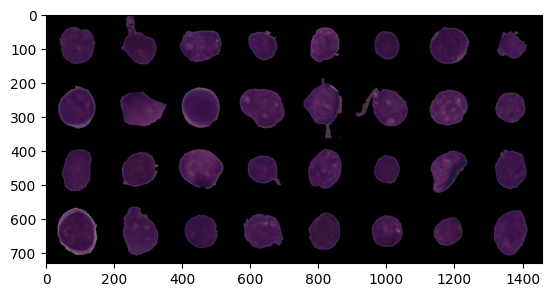

In [62]:
from torchvision.utils import make_grid

loader = torch.utils.data.DataLoader(train_data, shuffle=True, batch_size=32)

  
batch, labels = next(iter(loader))

grid = make_grid(batch).permute(1, 2, 0) # результатом є тензор

plt.imshow(grid)